Exercise 1: Multi-Layered Scatter Plot with Marginal Histograms

Objective:

Create a multi-layered scatter plot using plotnine that includes marginal histograms to visualize the distribution of two continuous variables.
Instructions

    Choose a dataset with at least two continuous variables (e.g., the Iris dataset).
    Load your dataset into a pandas DataFrame.
    Import the necessary components from plotnine.
    Create a scatter plot mapping the two continuous variables to the x and y axes.
    Overlay this plot with marginal histograms along both the x and y axes to show the distribution of each variable.
    Customize the plot with titles, labels, and a color scheme that enhances data interpretation.
    Display the plot.

Expected Learning Outcome:

Develop skills in creating advanced, multi-layered visualizations that combine scatter plots with histograms using plotnine.

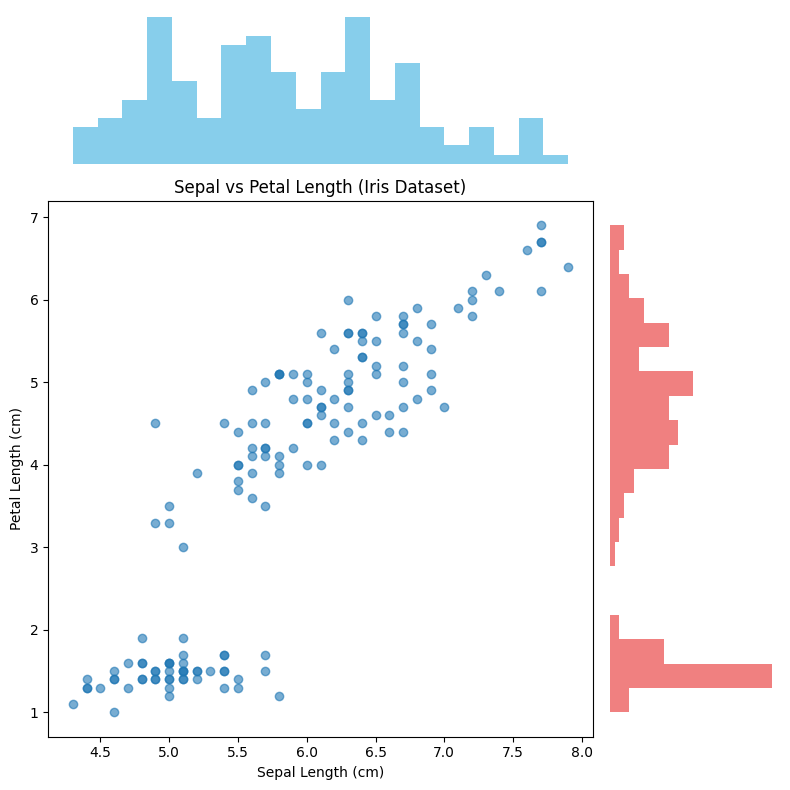

In [1]:
import pandas as pd
from plotnine import ggplot, aes, geom_point, theme_minimal, labs, theme
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn import datasets

iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

x = df['sepal length (cm)']
y = df['petal length (cm)']

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(4, 4)

ax_main = plt.subplot(gs[1:4, 0:3])
ax_main.scatter(x, y, alpha=0.6)
ax_main.set_xlabel('Sepal Length (cm)')
ax_main.set_ylabel('Petal Length (cm)')
ax_main.set_title('Sepal vs Petal Length (Iris Dataset)')

ax_xhist = plt.subplot(gs[0, 0:3], sharex=ax_main)
ax_xhist.hist(x, bins=20, color='skyblue')
ax_xhist.axis('off')

ax_yhist = plt.subplot(gs[1:4, 3], sharey=ax_main)
ax_yhist.hist(y, bins=20, orientation='horizontal', color='lightcoral')
ax_yhist.axis('off')

plt.tight_layout()
plt.show()

Exercise 2: Interactive Facet Grid with Conditional Elements

Objective:

Use plotnine to create an interactive facet grid that displays different types of plots (scatter plot, line plot, etc.) based on a categorical variable in the dataset.
Instructions

    Select a dataset with both categorical and continuous variables.
    Load the dataset into a pandas DataFrame.
    Import plotnine and other necessary libraries.
    Create a facet grid that segments your data by the categorical variable.
    Within each facet, implement a conditional statement that chooses the type of plot (scatter, line, etc.) based on the specific subset of data.
    Ensure interactivity, such as tooltips or hover information, where applicable.
    Customize the plot with appropriate titles, axis labels, and a legend.

Expected Learning Outcome:

Gain experience in creating complex, conditional visualizations using facet grids in plotnine.

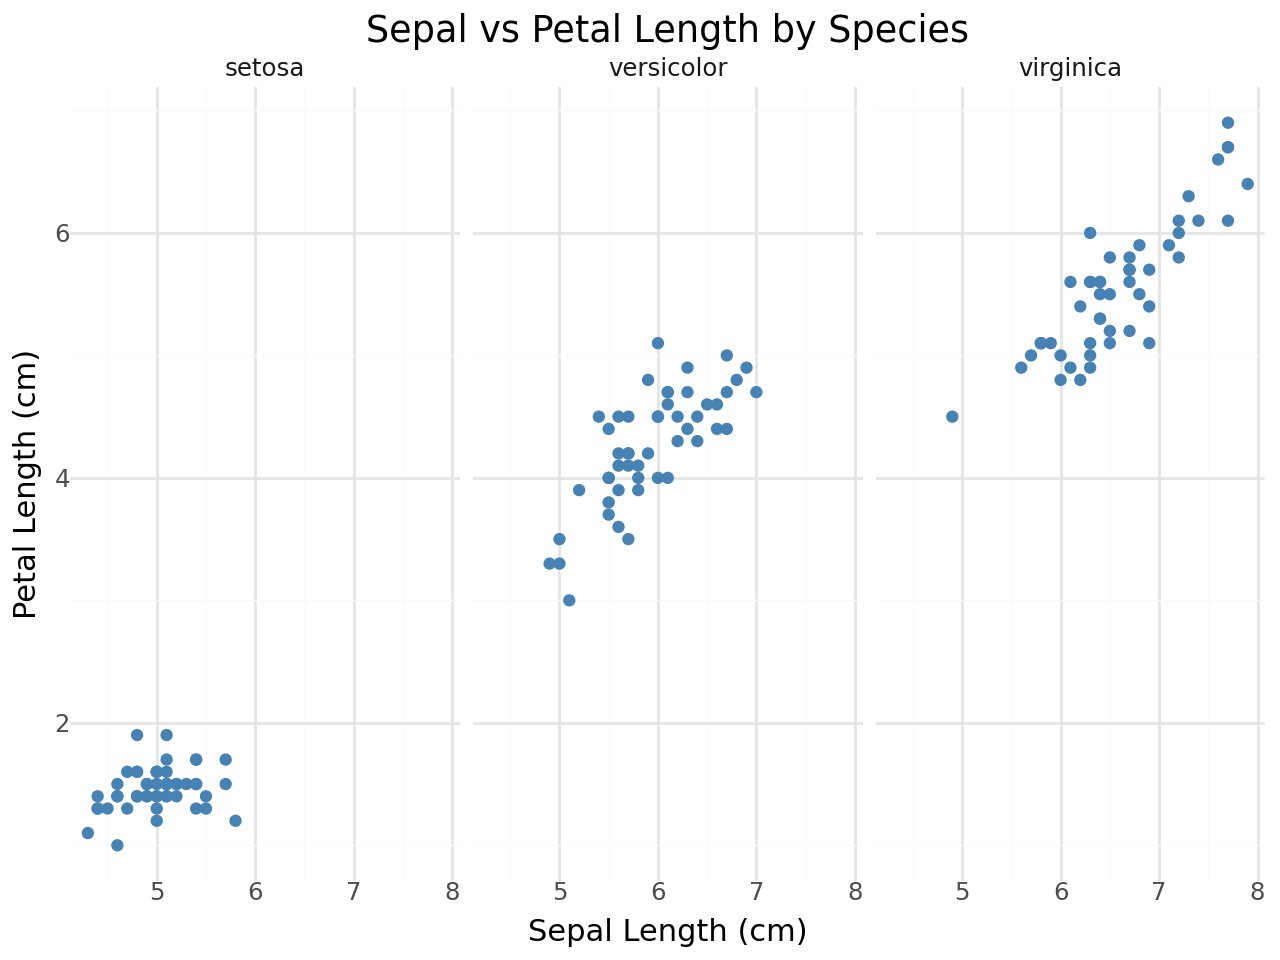

In [3]:
from plotnine import *
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

plot = (
    ggplot(df, aes(x='sepal length (cm)', y='petal length (cm)')) +
    geom_point(color='steelblue') +
    facet_wrap('~species') +
    labs(
        title='Sepal vs Petal Length by Species',
        x='Sepal Length (cm)',
        y='Petal Length (cm)'
    ) +
    theme_minimal()
)

plot

Exercise 3: Time Series Analysis with Rolling Averages and Confidence Intervals

Objective:

Perform a time series analysis on a dataset using plotnine by plotting rolling averages along with confidence intervals.
Instructions

    Choose a time series dataset (e.g., stock market data, temperature over time).
    Load the dataset into a pandas DataFrame.
    Calculate the rolling average and confidence intervals for a chosen time period.
    Import plotnine and other necessary libraries.
    Plot the time series data along with the rolling averages.
    Add shaded areas to represent confidence intervals around the rolling averages.
    Customize your plot with titles, labels, and an intuitive color scheme.

Expected Learning Outcome:

Learn to perform advanced time series analysis and visualization, incorporating statistical measures like rolling averages and confidence intervals.

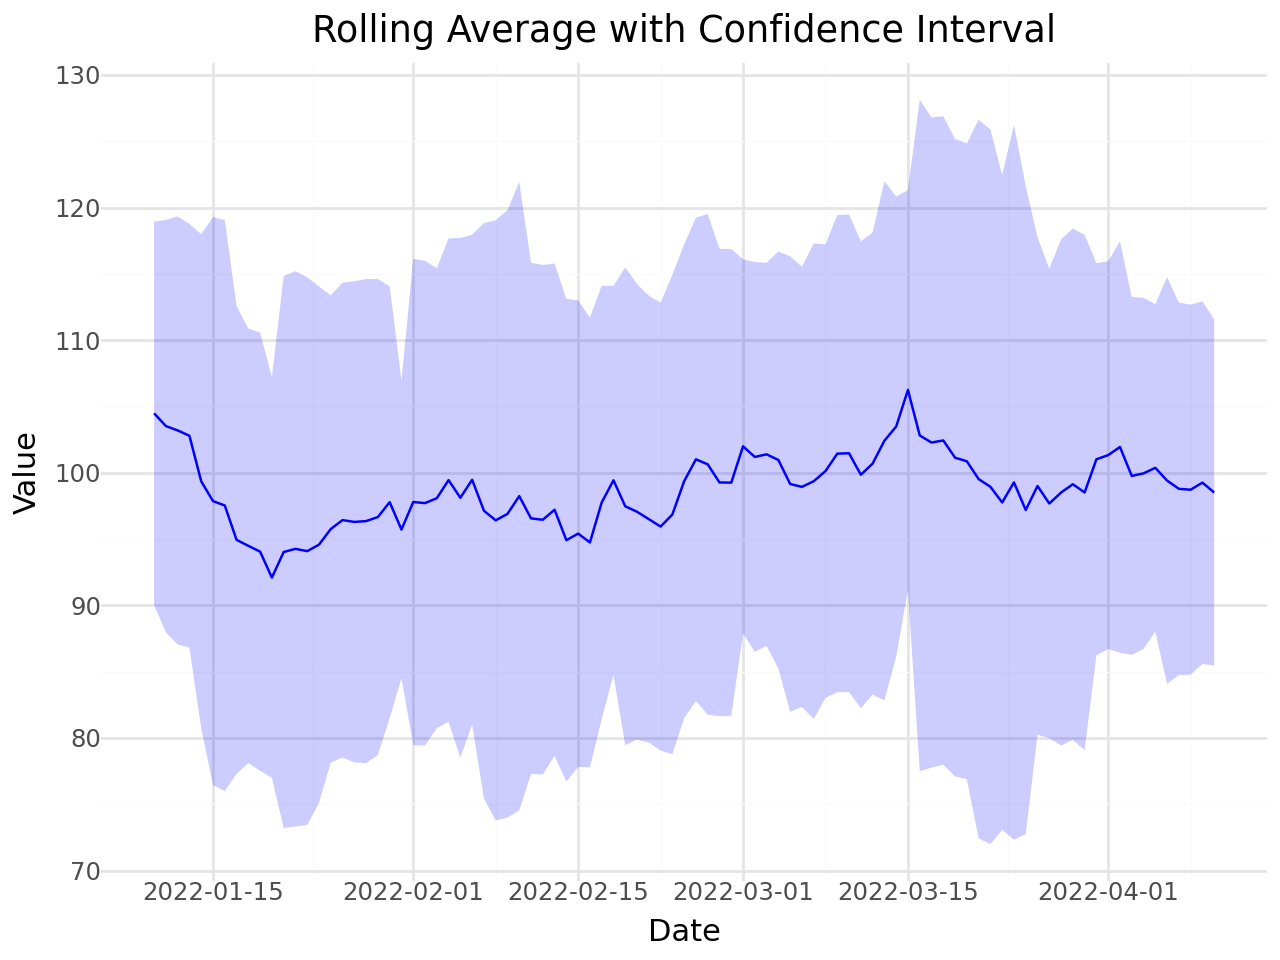

In [5]:
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_line, geom_ribbon, labs, theme_minimal
)
from IPython.display import display

np.random.seed(42)
df = pd.DataFrame({
    'date': pd.date_range(start='2022-01-01', periods=100),
    'value': np.random.normal(loc=100, scale=10, size=100)
})

window = 10
df['rolling_mean'] = df['value'].rolling(window=window).mean()
df['rolling_std'] = df['value'].rolling(window=window).std()
df['ci_upper'] = df['rolling_mean'] + 2 * df['rolling_std']
df['ci_lower'] = df['rolling_mean'] - 2 * df['rolling_std']

# Drop NaN values
df_clean = df.dropna()


plot = (
    ggplot(df_clean, aes(x='date', y='rolling_mean')) +
    geom_line(color='blue') +
    geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper'), fill='blue', alpha=0.2) +
    labs(
        title='Rolling Average with Confidence Interval',
        x='Date',
        y='Value'
    ) +
    theme_minimal()
)

# Step 6: Display the Plot
display(plot)